In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
import env_fpl_simulator
from tqdm import tqdm

from dqn_agent import DQN, ReplayBuffer, to_tensor
from env_fpl_simulator import SoloFPLTransferEnv
from data_loader import load_fpl_data


In [2]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
EPISODES = 100  # Reduced for CPU
BATCH_SIZE = 16
GAMMA = 0.99
LR = 1e-3
TARGET_UPDATE_FREQ = 10
EPS_START = 1.0
EPS_END = 0.1
EPS_DECAY = 0.995
BUFFER_CAPACITY = 5000

# Load data and environment
df = load_fpl_data("cleaned_fpl_data_2021-22.csv")
env = SoloFPLTransferEnv(df)
input_dim = 15 * 6  # 15 players, 6 stats each
output_dim = 1

# Initialize policy and target networks
policy_net = DQN(input_dim, output_dim).to(device)
target_net = DQN(input_dim, output_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
buffer = ReplayBuffer(BUFFER_CAPACITY)
epsilon = EPS_START

Using device: cpu
Loaded and cleaned data for season 2021-22, shape: (25447, 16)


In [3]:
def generate_trade_options(df, current_player, gw, top_k=3):
    player_rows = df[(df["name"] == current_player) & (df["round"] == gw)]
    if player_rows.empty:
        return []

    pos = player_rows["position"].values[0]
    curr_pred = player_rows["total_points"].values[0]
    pool = df[(df["position"] == pos) & (df["round"] == gw)]
    pool = pool[pool["name"] != current_player].copy()
    pool["similarity"] = (pool["total_points"] - curr_pred).abs()
    pool = pool.sort_values(by="similarity")
    return pool["name"].head(top_k).tolist()

def state_to_tensor(state, df, gw):
    player_rows = []
    for name in state:
        row = df[(df["name"] == name) & (df["round"] == gw)].head(1)
        if row.empty:
            player_rows.append(np.zeros(6))  # fallback if player missing
        else:
            player_rows.append(row[["minutes", "goals_scored", "assists", "influence", "ict_index", "value"]].values[0])
    return np.array(player_rows).flatten()

def flatten_squad(squad):
    return [player for pos in squad for player in squad[pos]]

def sample_random_action(env):
    trades = []
    for player in flatten_squad(env.squad):
        options = generate_trade_options(env.df, player, env.current_gw)
        for opt in options:
            trades.append((player, opt))
    return random.choice(trades) if trades else None

In [4]:
# === Training Loop ===
all_rewards = []
all_losses = []

for episode in tqdm(range(EPISODES)):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        state_vec = state_to_tensor(state, df, env.current_gw)
        state_tensor = torch.FloatTensor(state_vec).unsqueeze(0).to(device)

        if random.random() < epsilon:
            action = sample_random_action(env)
        else:
            with torch.no_grad():
                q_val = policy_net(state_tensor).item()
            action = env.select_best_action_based_on_state(q_val)

        next_state, reward, done, _ = env.step(action)
        next_state_vec = state_to_tensor(next_state, df, env.current_gw)

        buffer.push(state_vec, 0, reward, next_state_vec, done)
        total_reward += reward

        if len(buffer) >= BATCH_SIZE:
            states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)
            states = torch.FloatTensor(states).to(device)
            next_states = torch.FloatTensor(next_states).to(device)
            rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
            dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

            q_vals = policy_net(states)
            next_q_vals = target_net(next_states).detach()
            targets = rewards + GAMMA * next_q_vals * (1 - dones)

            loss = nn.MSELoss()(q_vals, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            all_losses.append(loss.item())

        state = next_state

    all_rewards.append(total_reward)
    epsilon = max(EPS_END, epsilon * EPS_DECAY)

    if episode % TARGET_UPDATE_FREQ == 0:
        target_net.load_state_dict(policy_net.state_dict())

    print(f"Episode {episode+1} | Total Reward: {total_reward:.2f} | Epsilon: {epsilon:.3f}")

  1%|          | 1/100 [00:03<05:04,  3.07s/it]

Episode 1 | Total Reward: -10.00 | Epsilon: 0.995


  2%|▏         | 2/100 [00:06<05:02,  3.08s/it]

Episode 2 | Total Reward: -9.00 | Epsilon: 0.990


  3%|▎         | 3/100 [00:09<04:56,  3.06s/it]

...

Episode 98 | Total Reward: 8.00 | Epsilon: 0.612


 99%|█████████▉| 99/100 [05:04<00:03,  3.35s/it]

Episode 99 | Total Reward: -5.00 | Epsilon: 0.609


100%|██████████| 100/100 [05:07<00:00,  3.08s/it]

Episode 100 | Total Reward: -5.00 | Epsilon: 0.606


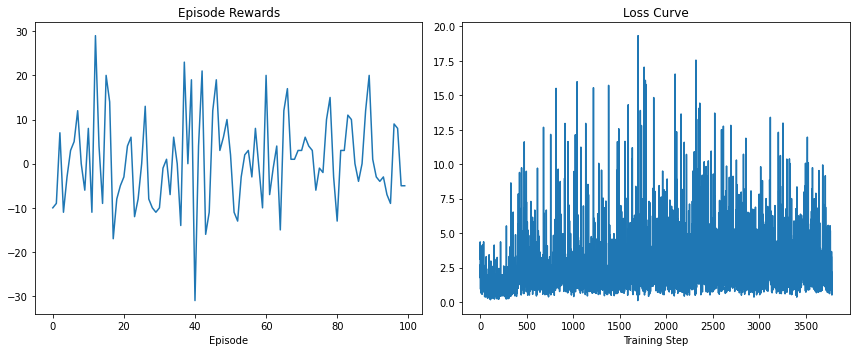

In [5]:
torch.save(policy_net.state_dict(), "fpl_model_dqn.pth")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(all_rewards)
plt.title("Episode Rewards")
plt.xlabel("Episode")

plt.subplot(1, 2, 2)
plt.plot(all_losses)
plt.title("Loss Curve")
plt.xlabel("Training Step")
plt.tight_layout()
plt.show()
